# RCA v5 — Why is PBO = 65.9% for ORB + ITSM?

**Source:** cscv_v5.ipynb (60 variants, S=16, 12,870 combinations, all with use_itsm_filter=True)

**Goal:** Decompose the high PBO to identify which parameter dimensions drive overfitting,
which variants are robust OOS, and whether the v5 candidate (SL=70/TP=140/OR=8/EMA=10) should proceed.

Sections:
1. Parameter Selection Frequency
2. PBO by Parameter Dimension
3. Root Cause of Negative OLS Slope
4. OOS Rank Stability by Variant
5. Summary & Conclusions

In [1]:
import asyncio
asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

In [2]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

THIS_DIR     = os.path.dirname(os.path.abspath('__file__'))
PROJECT_ROOT = os.path.abspath(os.path.join(THIS_DIR, '..', '..'))
NOTEBOOK_DIR = os.path.join(PROJECT_ROOT, 'notebooks', 'ORB_ITSM')

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
if NOTEBOOK_DIR not in sys.path:
    sys.path.insert(0, NOTEBOOK_DIR)

from data_fetch import fetch_data
from cscv_itsm import build_pnl_matrix, run_cscv, sharpe_cols, pbo_verdict

print('Setup complete.')

Setup complete.


In [3]:
df = fetch_data(refresh=False)
print(f'Bars loaded : {len(df):,}')
print(f'Date range  : {df.index[0].date()} -> {df.index[-1].date()}')

[data_fetch] Loading cached data from C:\Users\kunpa\Downloads\Projects\Futures_v2\data\NQ_5m.csv ...


[data_fetch] Loaded 222,295 rows (2014-12-19 -> 2026-03-17)
Bars loaded : 222,295
Date range  : 2014-12-19 -> 2026-03-17


In [4]:
SL_TP_PAIRS  = [(40, 80), (50, 100), (60, 120), (70, 140), (80, 160)]
OR_BARS_LIST = [4, 6, 8]
EMA_PERIODS  = [10, 15, 20, 25]

variants = [
    {
        'sl_points':       sl,
        'tp_points':       tp,
        'or_bars':         orb,
        'ema_period':      ema,
        'use_itsm_filter': True,
    }
    for (sl, tp) in SL_TP_PAIRS
    for orb in OR_BARS_LIST
    for ema in EMA_PERIODS
]

N = len(variants)
print(f'N = {N} variants')

print('Building P&L matrix...')
M, dates = build_pnl_matrix(df, variants)
T = M.shape[0]
print(f'P&L matrix shape: {M.shape}')

S = 16
results = run_cscv(M, S=S)

pbo               = results['pbo']
logits            = results['logits']
is_sharpes        = results['is_sharpes']
oos_sharpes       = results['oos_sharpes']
selected_variants = results['selected_variants']
full_sharpes      = sharpe_cols(M)

print(f'\nPBO = {pbo*100:.1f}%  {pbo_verdict(pbo)}')

N = 60 variants
Building P&L matrix...


  10/60 variants complete...


  20/60 variants complete...


  30/60 variants complete...


  40/60 variants complete...


  50/60 variants complete...


  60/60 variants complete...


P&L matrix shape: (2246, 60)



PBO = 65.9%  HIGH OVERFITTING RISK (PBO >= 50%)


---
## Section 1 — Parameter Selection Frequency

**Question:** Which parameter combinations dominate IS selection?

If selection is concentrated in a few variants, those variants determine the overall PBO.
High overfit rate when selected = the variant wins IS by fitting noise, not genuine edge.

In [5]:
from IPython.display import display, Markdown

selection_counts = np.bincount(selected_variants, minlength=N)

overfit_rate = np.zeros(N)
for v_idx in range(N):
    mask = selected_variants == v_idx
    if mask.sum() > 0:
        overfit_rate[v_idx] = (logits[mask] < 0).mean()

rows = []
for i, v in enumerate(variants):
    rows.append({
        'Variant':              i,
        'SL/TP':                f'{v["sl_points"]}/{v["tp_points"]}',
        'OR bars':              v['or_bars'],
        'EMA':                  v['ema_period'],
        'Times selected':       selection_counts[i],
        'Overfit rate':         f'{overfit_rate[i]*100:.1f}%',
        'Full-dataset Sharpe':  round(full_sharpes[i], 3),
    })
sel_df = pd.DataFrame(rows).sort_values('Times selected', ascending=False)

display(Markdown('### Top 10 Most-Selected Variants'))
display(sel_df.head(10).reset_index(drop=True))

print(f'\nTotal selections    : {selection_counts.sum():,}  (= n_combos {results["n_combos"]:,})')
print(f'Variants never selected: {(selection_counts == 0).sum()} / {N}')

### Top 10 Most-Selected Variants

,Variant,SL/TP,OR bars,EMA,Times selected,Overfit rate,Full-dataset Sharpe
0,24,60/120,4,10,3979,18.7%,1.086
1,0,40/80,4,10,2320,96.5%,0.981
2,12,50/100,4,10,2277,58.3%,1.054
3,20,50/100,8,10,1569,98.0%,0.945
4,44,70/140,8,10,842,94.7%,0.952
5,8,40/80,8,10,564,100.0%,0.764
6,56,80/160,8,10,468,100.0%,0.890
7,28,60/120,6,10,448,99.3%,0.912
8,48,80/160,4,10,287,83.6%,0.965
9,16,50/100,6,10,106,100.0%,0.860



Total selections    : 12,870  (= n_combos 12,870)
Variants never selected: 48 / 60


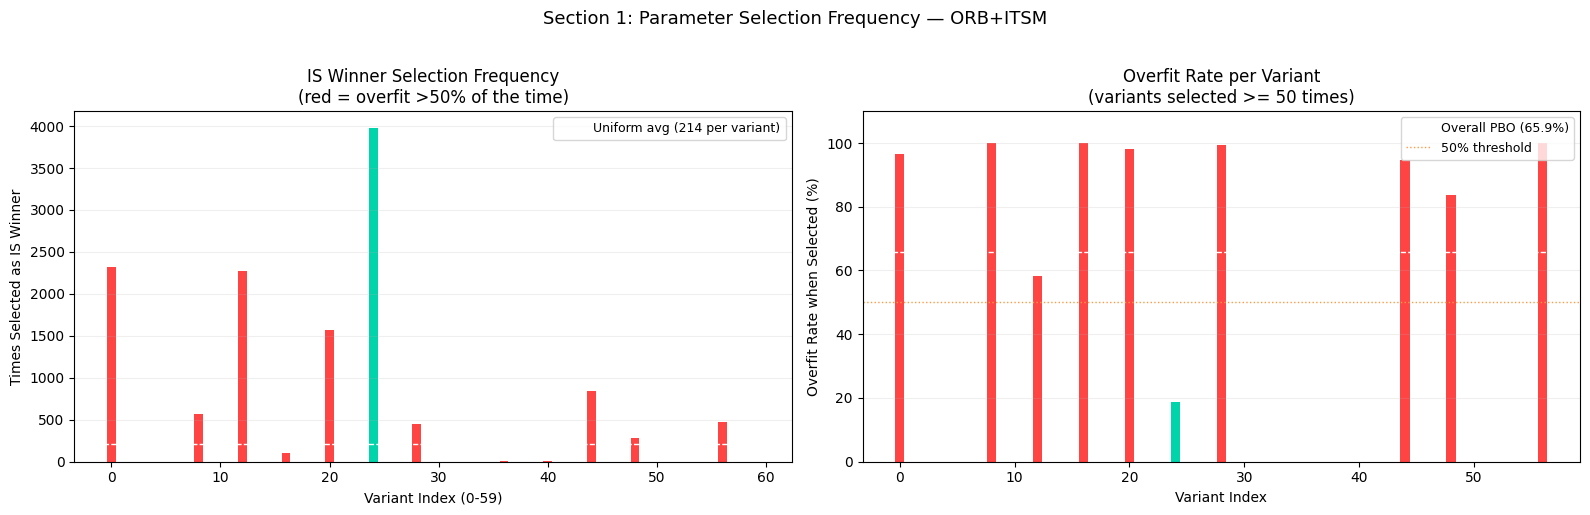

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
colors = ['#ff4444' if overfit_rate[i] > 0.5 else '#00d4aa' for i in range(N)]
ax.bar(range(N), selection_counts, color=colors, width=0.8)
ax.axhline(results['n_combos'] / N, color='white', linewidth=1, linestyle='--',
           label=f'Uniform avg ({results["n_combos"] // N} per variant)')
ax.set_xlabel('Variant Index (0-59)')
ax.set_ylabel('Times Selected as IS Winner')
ax.set_title('IS Winner Selection Frequency\n(red = overfit >50% of the time)')
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.2)

ax = axes[1]
active = selection_counts >= 50
xs = np.where(active)[0]
ys = overfit_rate[active]
bar_colors = ['#ff4444' if y > 0.5 else '#00d4aa' for y in ys]
ax.bar(xs, ys * 100, color=bar_colors, width=0.8)
ax.axhline(pbo * 100, color='white', linewidth=1, linestyle='--',
           label=f'Overall PBO ({pbo*100:.1f}%)')
ax.axhline(50, color='#ff9944', linewidth=1, linestyle=':', label='50% threshold')
ax.set_xlabel('Variant Index')
ax.set_ylabel('Overfit Rate when Selected (%)')
ax.set_title('Overfit Rate per Variant\n(variants selected >= 50 times)')
ax.set_ylim(0, 110)
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.2)

plt.suptitle('Section 1: Parameter Selection Frequency — ORB+ITSM', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## Section 2 — PBO by Parameter Dimension

**Question:** Is SL/TP, OR bars, or EMA period the primary driver of overfitting?

For each dimension, compute PBO within each group. Largest spread = primary driver.

C:\Users\kunpa\AppData\Local\Temp\ipykernel_22548\3950962709.py:10: RuntimeWarning: Mean of empty slice.
  pbos.append(overfit[mask].mean() * 100)
C:\Users\kunpa\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


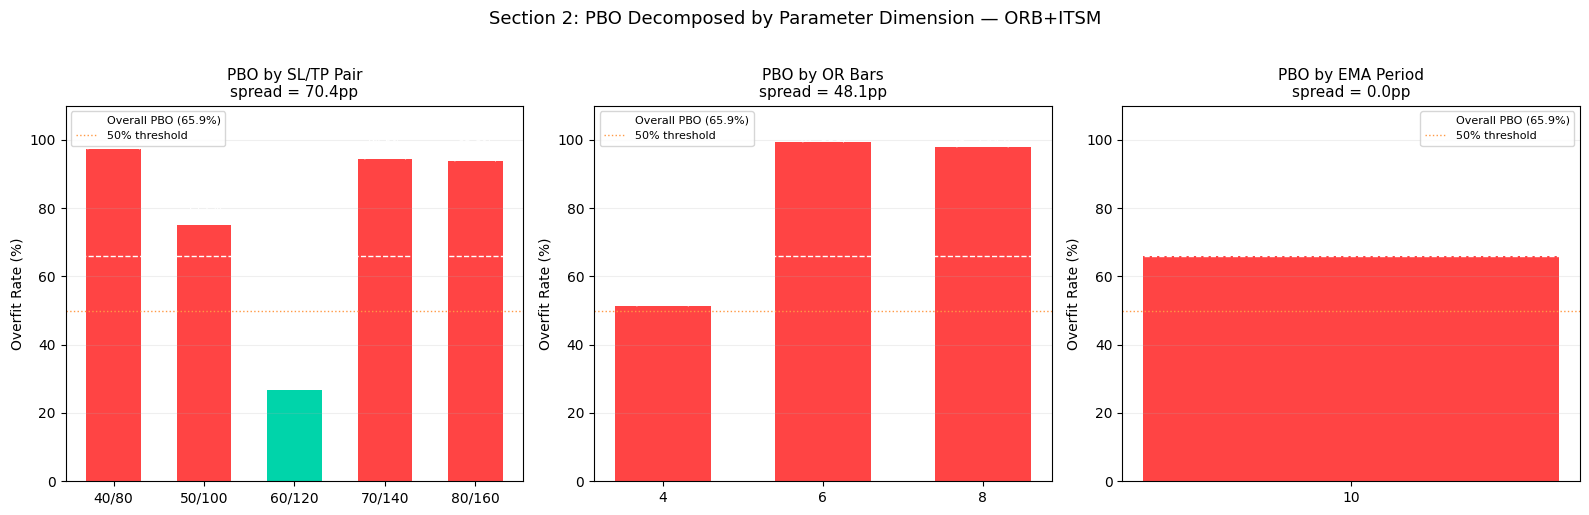

PBO spread by dimension:
  SL/TP          : 70.4 pp
  OR bars        : 48.1 pp
  EMA period     : 0.0 pp

Primary driver: SL/TP


In [7]:
sel_sl  = np.array([variants[v]['sl_points'] for v in selected_variants])
sel_or  = np.array([variants[v]['or_bars']   for v in selected_variants])
sel_ema = np.array([variants[v]['ema_period'] for v in selected_variants])
overfit = logits < 0

def pbo_by_dim(dim_vals, unique_vals):
    pbos, counts = [], []
    for u in unique_vals:
        mask = dim_vals == u
        pbos.append(overfit[mask].mean() * 100)
        counts.append(mask.sum())
    return pbos, counts

sl_unique  = [sl for sl, _ in SL_TP_PAIRS]
sl_pbos,  sl_counts  = pbo_by_dim(sel_sl,  sl_unique)
or_pbos,  or_counts  = pbo_by_dim(sel_or,  OR_BARS_LIST)
ema_pbos, ema_counts = pbo_by_dim(sel_ema, EMA_PERIODS)
sl_labels = [f'{sl}/{tp}' for (sl, tp) in SL_TP_PAIRS]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, labels, pbos, counts, title in [
    (axes[0], sl_labels,                  sl_pbos,  sl_counts,  'SL/TP Pair'),
    (axes[1], [str(v) for v in OR_BARS_LIST], or_pbos, or_counts, 'OR Bars'),
    (axes[2], [str(v) for v in EMA_PERIODS],  ema_pbos, ema_counts, 'EMA Period'),
]:
    bar_colors = ['#ff4444' if p > 50 else '#00d4aa' for p in pbos]
    bars = ax.bar(labels, pbos, color=bar_colors, width=0.6)
    ax.axhline(pbo * 100, color='white', linewidth=1, linestyle='--',
               label=f'Overall PBO ({pbo*100:.1f}%)')
    ax.axhline(50, color='#ff9944', linewidth=1, linestyle=':', label='50% threshold')
    for bar, p, c in zip(bars, pbos, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{p:.1f}%\n(n={c:,})', ha='center', fontsize=8, color='white')
    ax.set_title(f'PBO by {title}\nspread = {max(pbos)-min(pbos):.1f}pp', fontsize=11)
    ax.set_ylabel('Overfit Rate (%)')
    ax.set_ylim(0, 110)
    ax.legend(fontsize=8)
    ax.grid(True, axis='y', alpha=0.2)

plt.suptitle('Section 2: PBO Decomposed by Parameter Dimension — ORB+ITSM', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

spreads = {
    'SL/TP':      max(sl_pbos)  - min(sl_pbos),
    'OR bars':    max(or_pbos)  - min(or_pbos),
    'EMA period': max(ema_pbos) - min(ema_pbos),
}
primary_driver = max(spreads, key=spreads.get)
print('PBO spread by dimension:')
for k, v in sorted(spreads.items(), key=lambda x: -x[1]):
    print(f'  {k:15s}: {v:.1f} pp')
print(f'\nPrimary driver: {primary_driver}')

---
## Section 3 — Root Cause of Negative OLS Slope

**Question:** Why does higher IS Sharpe predict worse OOS Sharpe?

High IS Sharpe + collapse OOS = variant was lucky on the IS window, not genuinely better.
Identifying which variants occupy the high-IS / low-OOS region explains the negative slope.

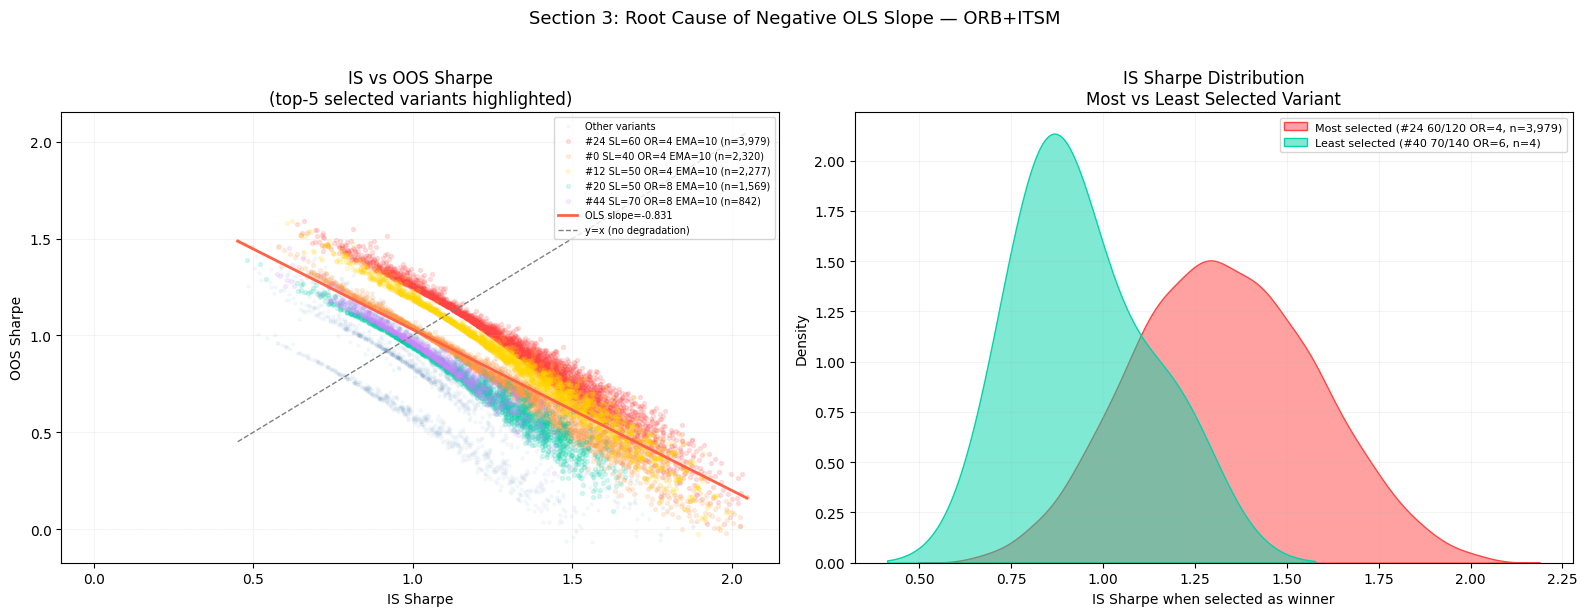

Most-selected variant #24: {'sl_points': 60, 'tp_points': 120, 'or_bars': 4, 'ema_period': 10, 'use_itsm_filter': True}
  Mean IS Sharpe when selected : 1.331
  Mean OOS Sharpe when selected: 0.919
  Overfit rate                 : 18.7%


In [8]:
top5_variants = np.argsort(selection_counts)[::-1][:5]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
is_top5 = np.isin(selected_variants, top5_variants)
ax.scatter(is_sharpes[~is_top5], oos_sharpes[~is_top5],
           alpha=0.04, s=5, color='steelblue', label='Other variants')
colors_top5 = ['#ff4444', '#ff9944', '#ffd700', '#00d4aa', '#cc88ff']
for rank, v_idx in enumerate(top5_variants):
    mask = selected_variants == v_idx
    v = variants[v_idx]
    label = f'#{v_idx} SL={v["sl_points"]} OR={v["or_bars"]} EMA={v["ema_period"]} (n={mask.sum():,})'
    ax.scatter(is_sharpes[mask], oos_sharpes[mask],
               alpha=0.15, s=8, color=colors_top5[rank], label=label)

valid = np.isfinite(is_sharpes) & np.isfinite(oos_sharpes)
m, b = np.polyfit(is_sharpes[valid], oos_sharpes[valid], 1)
xs = np.linspace(is_sharpes[valid].min(), is_sharpes[valid].max(), 200)
ax.plot(xs, m * xs + b, color='tomato', linewidth=2, label=f'OLS slope={m:.3f}')
ax.plot(xs, xs, color='gray', linewidth=1, linestyle='--', label='y=x (no degradation)')
ax.axhline(0, color='white', linewidth=0.5, linestyle=':')
ax.axvline(0, color='white', linewidth=0.5, linestyle=':')
ax.set_xlabel('IS Sharpe')
ax.set_ylabel('OOS Sharpe')
ax.set_title('IS vs OOS Sharpe\n(top-5 selected variants highlighted)')
ax.legend(fontsize=7, loc='upper right')
ax.grid(True, alpha=0.15)

ax = axes[1]
most_sel  = top5_variants[0]
least_sel = np.where(selection_counts > 0)[0][np.argmin(selection_counts[selection_counts > 0])]

mask_most  = selected_variants == most_sel
mask_least = selected_variants == least_sel
if mask_most.sum() > 1:
    sns.kdeplot(is_sharpes[mask_most], ax=ax, fill=True, alpha=0.5, color='#ff4444',
                label=f'Most selected (#{most_sel} {variants[most_sel]["sl_points"]}/{variants[most_sel]["tp_points"]} OR={variants[most_sel]["or_bars"]}, n={mask_most.sum():,})')
if mask_least.sum() > 1:
    sns.kdeplot(is_sharpes[mask_least], ax=ax, fill=True, alpha=0.5, color='#00d4aa',
                label=f'Least selected (#{least_sel} {variants[least_sel]["sl_points"]}/{variants[least_sel]["tp_points"]} OR={variants[least_sel]["or_bars"]}, n={mask_least.sum()})')
ax.set_xlabel('IS Sharpe when selected as winner')
ax.set_ylabel('Density')
ax.set_title('IS Sharpe Distribution\nMost vs Least Selected Variant')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.15)

plt.suptitle('Section 3: Root Cause of Negative OLS Slope — ORB+ITSM', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'Most-selected variant #{most_sel}: {variants[most_sel]}')
print(f'  Mean IS Sharpe when selected : {is_sharpes[mask_most].mean():.3f}')
print(f'  Mean OOS Sharpe when selected: {oos_sharpes[mask_most].mean():.3f}')
print(f'  Overfit rate                 : {(logits[mask_most] < 0).mean()*100:.1f}%')

---
## Section 4 — OOS Rank Stability by Variant

**Question:** Which variants are consistently robust OOS, and which are fragile?

OOS success rate = fraction of times a variant was IS winner AND outperformed OOS median (logit >= 0).
A robust variant has high success rate AND high full-dataset Sharpe — both IS and OOS.

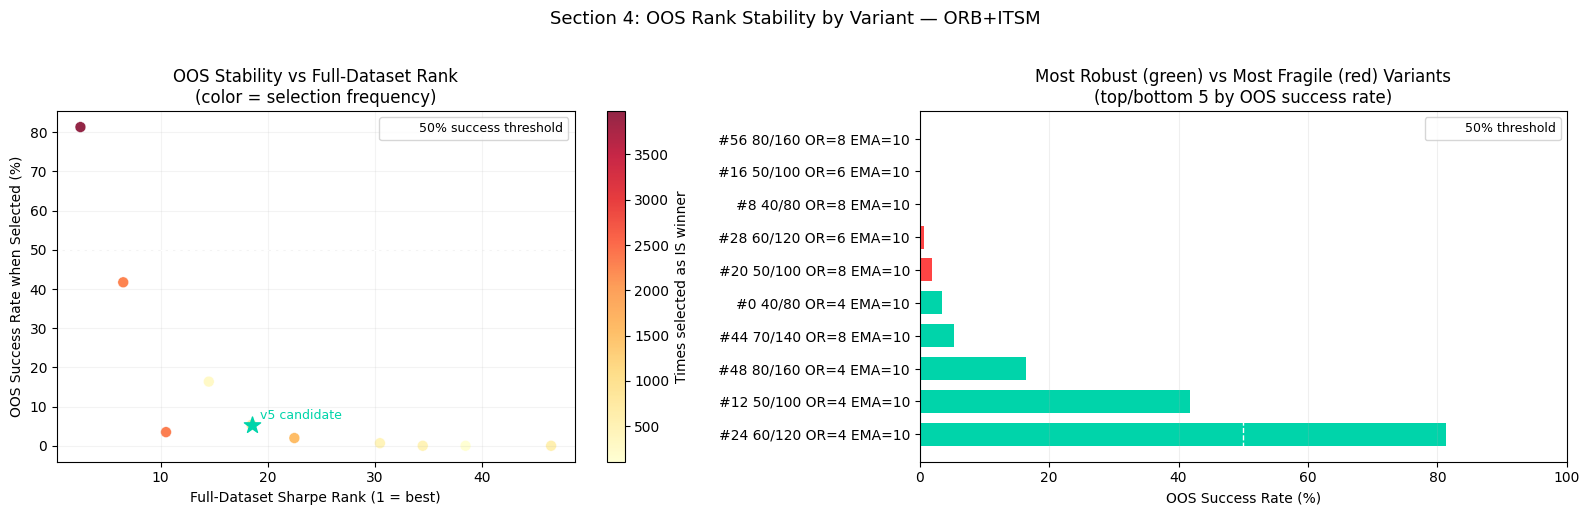

v5 candidate #44 (70/140 OR=8 EMA=10):
  OOS success rate : 5.3%
  Times selected   : 842
  Full-dataset rank: 18 / 60


In [9]:
oos_success_rate = np.full(N, np.nan)
for v_idx in range(N):
    mask = selected_variants == v_idx
    if mask.sum() >= 10:
        oos_success_rate[v_idx] = (logits[mask] >= 0).mean() * 100

sharpe_rank = N + 1 - pd.Series(full_sharpes).rank().values

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
valid_mask = ~np.isnan(oos_success_rate)
sc = ax.scatter(sharpe_rank[valid_mask], oos_success_rate[valid_mask],
                c=selection_counts[valid_mask], cmap='YlOrRd',
                s=60, alpha=0.85, edgecolors='white', linewidths=0.3)
plt.colorbar(sc, ax=ax, label='Times selected as IS winner')
ax.axhline(50, color='white', linewidth=1, linestyle='--', label='50% success threshold')

# Annotate v5 baseline
v5_idx = next(i for i, v in enumerate(variants)
              if v['sl_points']==70 and v['tp_points']==140
              and v['or_bars']==8   and v['ema_period']==10)
if not np.isnan(oos_success_rate[v5_idx]):
    ax.scatter(sharpe_rank[v5_idx], oos_success_rate[v5_idx],
               color='#00d4aa', s=150, zorder=5, marker='*')
    ax.annotate('v5 candidate',
                (sharpe_rank[v5_idx], oos_success_rate[v5_idx]),
                textcoords='offset points', xytext=(6, 4),
                fontsize=9, color='#00d4aa')

ax.set_xlabel('Full-Dataset Sharpe Rank (1 = best)')
ax.set_ylabel('OOS Success Rate when Selected (%)')
ax.set_title('OOS Stability vs Full-Dataset Rank\n(color = selection frequency)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.15)

ax = axes[1]
stability_df = pd.DataFrame({
    'variant':     range(N),
    'oos_success': oos_success_rate,
    'selections':  selection_counts,
    'full_sharpe': full_sharpes,
}).dropna(subset=['oos_success']).sort_values('oos_success', ascending=False)

top5_robust  = stability_df.head(5)
top5_fragile = stability_df.tail(5)
combined = pd.concat([top5_robust, top5_fragile])

def vlabel(idx):
    v = variants[int(idx)]
    return f'#{int(idx)} {v["sl_points"]}/{v["tp_points"]} OR={v["or_bars"]} EMA={v["ema_period"]}'

bar_colors = ['#00d4aa'] * 5 + ['#ff4444'] * 5
ax.barh([vlabel(r['variant']) for _, r in combined.iterrows()],
        combined['oos_success'], color=bar_colors, height=0.7)
ax.axvline(50, color='white', linewidth=1, linestyle='--', label='50% threshold')
ax.set_xlabel('OOS Success Rate (%)')
ax.set_title('Most Robust (green) vs Most Fragile (red) Variants\n(top/bottom 5 by OOS success rate)')
ax.set_xlim(0, 100)
ax.legend(fontsize=9)
ax.grid(True, axis='x', alpha=0.2)

plt.suptitle('Section 4: OOS Rank Stability by Variant — ORB+ITSM', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'v5 candidate #{v5_idx} ({variants[v5_idx]["sl_points"]}/{variants[v5_idx]["tp_points"]} OR={variants[v5_idx]["or_bars"]} EMA={variants[v5_idx]["ema_period"]}):')
if not np.isnan(oos_success_rate[v5_idx]):
    print(f'  OOS success rate : {oos_success_rate[v5_idx]:.1f}%')
    print(f'  Times selected   : {selection_counts[v5_idx]:,}')
    print(f'  Full-dataset rank: {int(sharpe_rank[v5_idx])} / {N}')
else:
    print('  Selected < 10 times -- insufficient data')

---
## Section 5 — Summary & Conclusions

In [10]:
from IPython.display import display, Markdown

most_robust_idx  = int(stability_df.iloc[0]['variant'])
most_fragile_idx = int(stability_df.iloc[-1]['variant'])
most_sel_idx     = int(np.argmax(selection_counts))
prob_loss        = float(np.mean(oos_sharpes < 0))

display(Markdown('### PBO Decomposition Summary'))
display(pd.DataFrame([
    ('Overall PBO',
     f'{pbo*100:.1f}%',
     pbo_verdict(pbo)),
    ('vs ORB-only PBO (v4)',
     '47.7% -> 65.9%',
     'ITSM filter increased overfitting risk (+18pp)'),
    ('Primary driver',
     primary_driver,
     f'Widest PBO spread: {spreads[primary_driver]:.1f}pp'),
    ('Most-selected variant',
     f'#{most_sel_idx}  {variants[most_sel_idx]["sl_points"]}/{variants[most_sel_idx]["tp_points"]} OR={variants[most_sel_idx]["or_bars"]} EMA={variants[most_sel_idx]["ema_period"]}',
     f'Selected {selection_counts[most_sel_idx]:,}x  |  overfit rate {overfit_rate[most_sel_idx]*100:.1f}%'),
    ('Most robust variant',
     f'#{most_robust_idx}  {variants[most_robust_idx]["sl_points"]}/{variants[most_robust_idx]["tp_points"]} OR={variants[most_robust_idx]["or_bars"]} EMA={variants[most_robust_idx]["ema_period"]}',
     f'OOS success rate {oos_success_rate[most_robust_idx]:.1f}%'),
    ('Most fragile variant',
     f'#{most_fragile_idx}  {variants[most_fragile_idx]["sl_points"]}/{variants[most_fragile_idx]["tp_points"]} OR={variants[most_fragile_idx]["or_bars"]} EMA={variants[most_fragile_idx]["ema_period"]}',
     f'OOS success rate {oos_success_rate[most_fragile_idx]:.1f}%'),
], columns=['Finding', 'Value', 'Detail']))

display(Markdown('### OLS Slope Root Cause'))
mask_most_sel = selected_variants == most_sel_idx
display(pd.DataFrame([
    ('OLS slope (IS vs OOS)',
     f'{m:.3f}',
     'Should be ~1.0 for robust strategy'),
    ('Root cause',
     'High-IS variants collapse OOS',
     'IS selection picks variants that overfit the IS window'),
    ('Evidence',
     f'Most-selected #{most_sel_idx}: IS {is_sharpes[mask_most_sel].mean():.3f} -> OOS {oos_sharpes[mask_most_sel].mean():.3f}',
     f'Mean OOS Sharpe drop of {(is_sharpes[mask_most_sel].mean()-oos_sharpes[mask_most_sel].mean()):.3f}'),
], columns=['Metric', 'Value', 'Interpretation']))

display(Markdown('### v5 Candidate Assessment'))
v5_success = oos_success_rate[v5_idx] if not np.isnan(oos_success_rate[v5_idx]) else None
v5_verdict = 'PROCEED' if (v5_success is not None and v5_success >= 50) else 'CAUTION'
display(pd.DataFrame([
    ('Parameters',                  'SL=70  TP=140  OR=8bars  EMA=10  ITSM=ON', ''),
    ('Full-dataset rank',            f'{int(sharpe_rank[v5_idx])} / {N}',        'Rank by Sharpe across all 60 variants'),
    ('Full-dataset Sharpe',          f'{full_sharpes[v5_idx]:.3f}',              ''),
    ('Times selected as IS winner',  f'{selection_counts[v5_idx]:,}',            ''),
    ('OOS success rate',             f'{v5_success:.1f}%' if v5_success else 'N/A', '% of times selected -> logit >= 0'),
    ('Prob(loss OOS)',               f'{prob_loss*100:.1f}%',                    'fraction of CSCV splits with negative OOS Sharpe'),
    ('Forward Sharpe estimate',      f'~{np.median(oos_sharpes):.2f}',           'OOS median Sharpe'),
    ('Verdict',                      v5_verdict,                                 'PROCEED if OOS success >= 50%'),
], columns=['Metric', 'Value', 'Notes']))

### PBO Decomposition Summary

,Finding,Value,Detail
0,Overall PBO,65.9%,HIGH OVERFITTING RISK (PBO >= 50%)
1,vs ORB-only PBO (v4),47.7% -> 65.9%,ITSM filter increased overfitting risk (+18pp)
2,Primary driver,SL/TP,Widest PBO spread: 70.4pp
3,Most-selected variant,#24 60/120 OR=4 EMA=10,"Selected 3,979x | overfit rate 18.7%"
4,Most robust variant,#24 60/120 OR=4 EMA=10,OOS success rate 81.3%
5,Most fragile variant,#56 80/160 OR=8 EMA=10,OOS success rate 0.0%


### OLS Slope Root Cause

,Metric,Value,Interpretation
0,OLS slope (IS vs OOS),-0.831,Should be ~1.0 for robust strategy
1,Root cause,High-IS variants collapse OOS,IS selection picks variants that overfit the I...
2,Evidence,Most-selected #24: IS 1.331 -> OOS 0.919,Mean OOS Sharpe drop of 0.412


### v5 Candidate Assessment

,Metric,Value,Notes
0,Parameters,SL=70 TP=140 OR=8bars EMA=10 ITSM=ON,
1,Full-dataset rank,18 / 60,Rank by Sharpe across all 60 variants
2,Full-dataset Sharpe,0.952,
3,Times selected as IS winner,842,
4,OOS success rate,5.3%,% of times selected -> logit >= 0
5,Prob(loss OOS),0.1%,fraction of CSCV splits with negative OOS Sharpe
6,Forward Sharpe estimate,~0.82,OOS median Sharpe
7,Verdict,CAUTION,PROCEED if OOS success >= 50%
